In [1]:
import json
import pandas as pd

In [2]:
with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/math_genealogy_project/new-data/data-new.json',"r") as file:
    tree=json.load(file)

In [3]:
nodes=pd.DataFrame(tree["nodes"])

In [35]:
#338530 mpg entries as scraped on June 3
len(nodes)

338532

In [40]:
nodes.info()

<class 'pandas.DataFrame'>
Index: 338526 entries, 0 to 338531
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        338526 non-null  int64  
 1   name      338526 non-null  str    
 2   thesis    307399 non-null  str    
 3   school    281805 non-null  str    
 4   country   322986 non-null  str    
 5   year      277236 non-null  float64
 6   subject   202492 non-null  str    
 7   advisors  338526 non-null  object 
 8   students  338526 non-null  object 
dtypes: float64(1), int64(1), object(2), str(5)
memory usage: 68.1+ MB


In [46]:
nodes.sort_values(by='year').tail(10)

,id,name,thesis,school,country,year,subject,advisors,students
338464,346056,Juan Manuel Vilar,NaN,NaN,NaN,NaN,NaN,[],"[346062, 346055, 346061]"
338471,346064,Margarita Poza Domínguez,NaN,NaN,NaN,NaN,NaN,[],[346063]
338475,346068,Catherine Legrand,NaN,NaN,NaN,NaN,NaN,[],"[346072, 346067]"
338481,346075,Jad Beyhum,NaN,NaN,NaN,NaN,NaN,[],"[346078, 346074]"
338495,346083,David Neil Hayes,NaN,NaN,NaN,NaN,NaN,[],"[346082, 346096, 201230]"
338497,346091,Dirk Dittmer,NaN,NaN,NaN,NaN,NaN,[],[346090]
338502,346094,Kai Zhang,NaN,NaN,NaN,NaN,NaN,[],"[346095, 346100, 346093]"
338514,346107,Charles Perou,NaN,NaN,NaN,NaN,NaN,[],[346106]
338521,346109,Hyejung Won,NaN,NaN,NaN,NaN,NaN,[],[346108]
338523,346113,Luca Manzoni,NaN,NaN,NaN,NaN,NaN,[],[346114]


In [33]:
nodes.loc[nodes['id'] == 95595, ['school', 'year']] = ['Université of Rennes 1', None]
nodes.loc[nodes['id'] == 80496, ['school', 'year']] = ['Université Bordeaux 1', None]
nodes.loc[nodes['id'] == 78148, ['school', 'year']] = ['Université Paris Diderot - Paris 7', None]
nodes.loc[nodes['id'] == 81006, ['school', 'year']] = ['Université Paris Diderot - Paris 7', None]
nodes.loc[nodes['id'] == 344761, 'year'] = 2022
nodes.loc[nodes['id'] == 261324, 'year'] = 2007
nodes.loc[nodes['id'] == 344359, 'year'] = 2022
nodes[nodes['id'] == 344359]

,id,name,thesis,school,country,year,subject,advisors,students
336776,344359,Elaina Aceves,Train tracks of pseudo-Anosov 3-braids and non...,The University of Iowa,UnitedStates,2022.0,57—Manifolds and cell complexes,[97534],[]


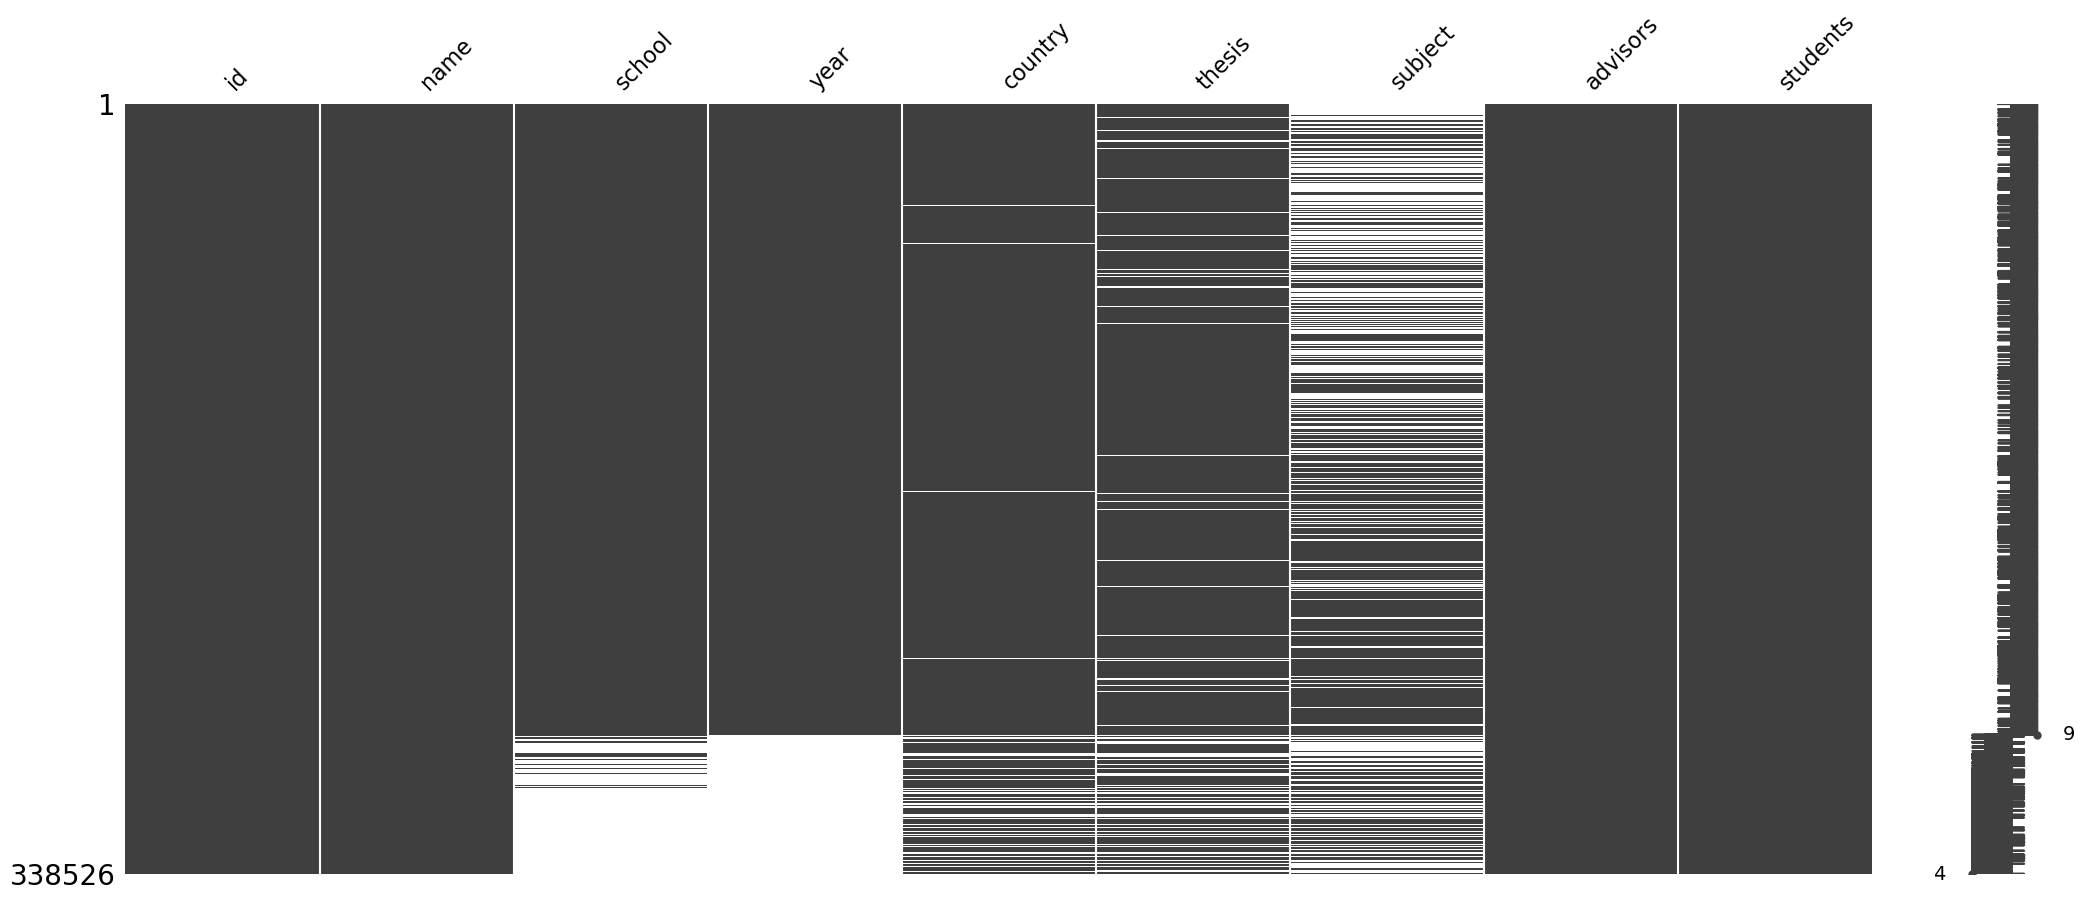

In [52]:
#missing data analysis
import matplotlib.pyplot as plt
import missingno as msno

msno.matrix(nodes.reindex(columns=['id','name','school', 'year', 'country','thesis','subject','advisors','students']).sort_values(by='year'))
plt.show()


## Observation of the missing data:
1. The year missing is correlated with school missing;
2. In the early years (near top on the black bar), the subjects tend to be missing; 
3. If the 'year' is missing, then 'country' and 'thesis' tend to be missing


In [47]:
nodes.sample(100)

,id,name,thesis,school,country,year,subject,advisors,students
11992,12024,Douglas Conner Ravenel,A Definition of Exotic Characteristic Classes,Brandeis University,UnitedStates,1972.0,NaN,[1465],"[25666, 186831, 26585, 12027, 26999, 12028, 15..."
299387,305525,Kim C. Raath,Dynamic Multivariate Wavelet Signal Extraction...,Rice University,UnitedStates,2020.0,62—Statistics,[46047],[]
336326,343903,Zenaw Asnake Fekadiea,Closed Range and Dynamical Structures of Volte...,Bahir Dar University,Ethiopia,2025.0,47—Operator theory,"[153256, 343902]",[]
212232,217070,Oana Goga,Matching User Accounts Across Online Social Ne...,Université Pierre-et-Marie-Curie - Paris VI,France,2014.0,68—Computer science,[180982],[]
156138,160191,Kimberly Michele Hopkins,Periods of Modular Forms and Central Values of...,University of Texas at Austin,UnitedStates,2010.0,11—Number theory,[10642],[]
...,...,...,...,...,...,...,...,...,...
275703,281609,Werner Knaup,Algebraische Strukturen in einfachen Warteschl...,NaN,Germany,NaN,68—Computer science,[130048],[]
238909,244112,Edward S. Fertik,"Steel and Sovereignty: The United States, Nati...",Yale University,UnitedStates,2018.0,"91—Game theory, economics, social and behavior...","[214715, 244111]",[]
46271,46589,Surgit Singh,NaN,,NaN,NaN,NaN,[],[46588]
242372,247631,Bikash Kumar Chinhara,Studies on Harmonic Univalent Mappings and its...,Sambalpur University,India,2019.0,30—Functions of a complex variable,[],[]


In [39]:
#find rows with empty names
nodes[nodes.name.fillna("").str.strip() == ""]
# perhaps we can drop the 5 rows which is completely empty

,id,name,thesis,school,country,year,subject,advisors,students


In [38]:
#Drop rows with empty/missing names:
nodes = nodes[nodes['name'].fillna("").str.strip() != ""]

In [37]:
nodes[(nodes['id'] == 29316) | (nodes['id'] == 100043)]

,id,name,thesis,school,country,year,subject,advisors,students
338530,29316,Detlef Dürr,Wahrscheinlichste Wege von Diffusionsprozessen,Universität Münster,Germany,1978.0,60—Probability theory and stochastic processes,[300879],"[49602, 191494, 273114, 28892, 28895, 171502, ..."
338531,100043,Dmitri Loguinov,Adaptive Scalable Internet Streaming,City University of New York,UnitedStates,2002.0,68—Computer science,[99811],"[231378, 231380, 120300, 123732, 150492, 23137..."


In [18]:
#adding entry for id=29316
new_row = {
  'id': 29316,
  'name': "Detlef Dürr",
  'thesis': "Wahrscheinlichste Wege von Diffusionsprozessen",
  'school': "Universität Münster",
  'country': "Germany",
  'year': 1978.0,
  'subject': "60—Probability theory and stochastic processes",
  'advisors': [300879],
  'students': [49602, 191494, 273114, 28892, 28895, 171502, 77148, 191496, 269414, 269415, 191498, 191492, 270001, 191495, 97197, 119112, 191501, 191499]
}
nodes = pd.concat([nodes, pd.DataFrame([new_row])], ignore_index=True)

In [19]:
#adding entry for id=100043
new_row_1 = {
  'id': 100043,
  'name': "Dmitri Loguinov",
  'thesis': "Adaptive Scalable Internet Streaming",
  'school': "City University of New York",
  'country': "UnitedStates",
  'year': 2002.0,
  'subject': "68—Computer science",
  'advisors': [99811],
  'students': [231378, 231380, 120300, 123732, 150492, 231377, 150493, 231379, 136368, 136548, 120361]
}
nodes = pd.concat([nodes, pd.DataFrame([new_row_1])], ignore_index=True)

In [ ]:
# turn 'year' to an integer (allow NaN)
nodes['year'] = pd.to_numeric(nodes['year'], errors='coerce').astype('Int64')

In [48]:
#add a new feature computing the number of students
nodes['number_of_students']=nodes['students'].apply(lambda x: len(x))
nodes['number_of_students'].describe()

count    338526.000000
mean          1.132439
std           3.996891
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         181.000000
Name: number_of_students, dtype: float64

In [49]:
count= nodes['number_of_students'].value_counts().sort_index()
proportions=(nodes['number_of_students'].value_counts()/len(nodes)).sort_index()

result=pd.concat([count, proportions], axis=1, keys=['count','proportion'])

In [50]:
print(result)

                     count  proportion
number_of_students                    
0                   255612    0.755073
1                    34759    0.102677
2                    12699    0.037513
3                     7313    0.021602
4                     4966    0.014669
...                    ...         ...
127                      1    0.000003
130                      1    0.000003
133                      1    0.000003
146                      1    0.000003
181                      1    0.000003

[104 rows x 2 columns]


In [42]:
import json
from collections import Counter


#with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/math_genealogy_project/new-data/data-new.json', "r", encoding="utf-8") as file:
#    database = json.load(file)

records = nodes


def to_int_set(value):
    """Convert an advisor/student list into a set of integer IDs."""
    if value is None:
        return set()

    if not isinstance(value, (list, tuple, set)):
        return set()

    result = set()

    for item in value:
        try:
            result.add(int(item))
        except (TypeError, ValueError):
            pass

    return result


# ---------------------------------------
# 1. Validate and index IDs
# ---------------------------------------

valid_records = []
invalid_id_records = []

for record in records:
    try:
        record_id = int(record["id"])
        valid_records.append((record_id, record))
    except (KeyError, TypeError, ValueError):
        invalid_id_records.append(record)

id_counts = Counter(record_id for record_id, _ in valid_records)

duplicate_ids = [
    record_id
    for record_id, count in id_counts.items()
    if count > 1
]

by_id = {
    record_id: record
    for record_id, record in valid_records
}


# ---------------------------------------
# 2. Check important fields
# ---------------------------------------

missing_names = [
    record_id
    for record_id, record in valid_records
    if not record.get("name")
]

completely_empty_records = [
    record_id
    for record_id, record in valid_records
    if not any(
        record.get(field)
        for field in [
            "name",
            "thesis",
            "school",
            "country",
            "year",
            "subject",
            "advisors",
            "students",
        ]
    )
]


# ---------------------------------------
# 3. Check references and reciprocity
# ---------------------------------------

dangling_advisor_links = []
dangling_student_links = []

advisor_student_mismatches = []
student_advisor_mismatches = []

for person_id, record in valid_records:
    advisors = to_int_set(record.get("advisors"))
    students = to_int_set(record.get("students"))

    for advisor_id in advisors:
        if advisor_id not in by_id:
            dangling_advisor_links.append((person_id, advisor_id))
        else:
            advisor_students = to_int_set(by_id[advisor_id].get("students"))

            if person_id not in advisor_students:
                advisor_student_mismatches.append(
                    (person_id, advisor_id)
                )

    for student_id in students:
        if student_id not in by_id:
            dangling_student_links.append((person_id, student_id))
        else:
            student_advisors = to_int_set(by_id[student_id].get("advisors"))

            if person_id not in student_advisors:
                student_advisor_mismatches.append(
                    (person_id, student_id)
                )


# ---------------------------------------
# 4. Print report
# ---------------------------------------

print("Total records:", len(records))
print("Unique valid IDs:", len(by_id))
print("Invalid ID records:", len(invalid_id_records))
print("Duplicate IDs:", len(duplicate_ids))
print("Missing names:", len(missing_names))
print("Completely empty records:", len(completely_empty_records))

print()
print("Dangling advisor links:", len(dangling_advisor_links))
print("Dangling student links:", len(dangling_student_links))
print("Advisor/student mismatches:", len(advisor_student_mismatches))
print("Student/advisor mismatches:", len(student_advisor_mismatches))

print()
print("Error IDs present in data:")
print("29316:", 29316 in by_id)
print("100043:", 100043 in by_id)

print()
print("First duplicate IDs:", duplicate_ids[:10])
print("First missing-name IDs:", missing_names[:10])
print("First dangling advisor links:", dangling_advisor_links[:10])
print("First dangling student links:", dangling_student_links[:10])
print("First relationship mismatches:", advisor_student_mismatches[:10])

Total records: 338526
Unique valid IDs: 0
Invalid ID records: 9
Duplicate IDs: 0
Missing names: 0
Completely empty records: 0

Dangling advisor links: 0
Dangling student links: 0
Advisor/student mismatches: 0
Student/advisor mismatches: 0

Error IDs present in data:
29316: False
100043: False

First duplicate IDs: []
First missing-name IDs: []
First dangling advisor links: []
First dangling student links: []
First relationship mismatches: []


In [51]:
nodes[(nodes['id'] == 28892) | (nodes['id'] == 29316)]

,id,name,thesis,school,country,year,subject,advisors,students,number_of_students
28747,28892,Karin Berndl,Zur Existenz der Dynamik in Bohmschen Systemen,Ludwig-Maximilians-Universität München,Germany,1995.0,NaN,[29316],[],0
338530,29316,Detlef Dürr,Wahrscheinlichste Wege von Diffusionsprozessen,Universität Münster,Germany,1978.0,60—Probability theory and stochastic processes,[300879],"[49602, 191494, 273114, 28892, 28895, 171502, ...",18


In [44]:
all_saved_ids = set(nodes["id"].astype(int))

for mgp_id in [29316, 100043]:
    print(mgp_id, mgp_id in all_saved_ids)

29316 True
100043 True


In [45]:
# Convert the modified DataFrame back to a list of dictionaries
tree["nodes"] = nodes.to_dict('records')

# Write back to the JSON file
with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/math_genealogy_project/new-data/data-new.json', 'w') as file:
    json.dump(tree, file, indent=2)